# Autonomous Agent란?

**Autonomous Agent**는 **높은 자율성**을 가지고 동적으로 의사결정하며 작업하는 가장 고급 형태의 Multi-Agent 패턴입니다.

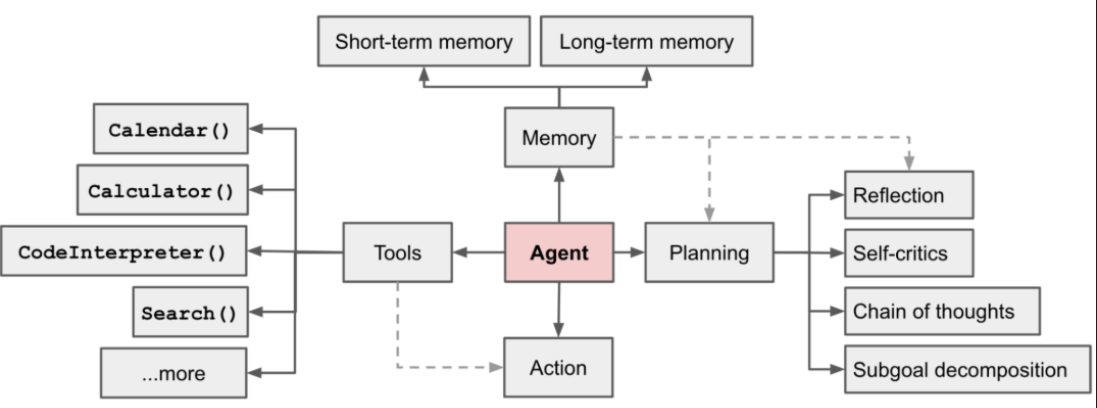

## 핵심 특징

1. **자율적 의사결정** (Autonomous Decision-Making)
   - 미리 정해진 경로가 아닌, 상황에 따라 스스로 판단
   - 목표 달성을 위한 최적의 경로 선택
   
2. **동적 워크플로우** (Dynamic Workflow)
   - 실행 중에 워크플로우가 변경됨
   - 조건에 따라 에이전트를 건너뛰거나 반복
   
3. **루프와 재귀** (Loop & Recursion)
   - 목표 달성까지 작업 반복
   - 결과가 만족스럽지 않으면 다시 시도
   
4. **Human-in-the-Loop (HITL)**
   - 중요한 결정에 사용자 개입
   - 사람의 판단과 AI의 자동화 결합

5. **메타인지** (Meta-cognition)
   - 자신의 작업을 평가하고 개선
   - "이 결과가 충분한가?" 스스로 판단


## 작동 방식

```
시작
  ↓
계획 수립 (Planning)
  ↓
작업 실행
  ↓
결과 검증 (Self-evaluation)
  ↓
만족스러운가?
  ├─ Yes → 완료
  └─ No → 추가 작업 필요
         ↓
      다시 계획 (Loop) 
         ↓
      반복...
```


## vs. 다른 패턴

| 패턴 | 워크플로우 | 자율성 | 반복 | 복잡도 |
|------|-----------|-------|------|--------|
| **Hierarchical** | 고정 | 낮음 | ❌ | ⭐ |
| **Sequential** | 고정 | 낮음 | ❌ | ⭐⭐ |
| **Collaborative** | 고정 | 중간 | ❌ | ⭐⭐⭐ |
| **Supervisor** | 반고정 | 중간 | △ | ⭐⭐⭐⭐ |
| **Autonomous** | **동적** | **높음** | **✅** | **⭐⭐⭐⭐⭐** |

# Multi Agents - 자율 연구 에이전트 (with Memory & interrupt)
LangGraph를 활용하여 동적 워크플로우, 루프/재귀, Human-in-the-loop 패턴을 구현하는 자율 연구 시스템을 만듭니다.

**주요 기능:**
- ✅ **MemorySaver**: 상태 지속성, 여러 세션 동시 관리
- ✅ **interrupt**: input() 없이 Human-in-the-Loop 구현
- ✅ **셀 단위 실행**: Jupyter 노트북에서 각 단계를 독립적으로 실행 가능
- ✅ **테스트 가능**: 자동화된 테스트 작성 가능

## 이 예제가 Autonomous Agent인 이유

**자율 연구 에이전트**는 Autonomous Agent의 모든 특징을 보여줍니다:

### 1. 자율적 의사결정
- **계획 에이전트**: 연구 주제를 스스로 분석하고 계획 수립
- **조정 에이전트**: "정보가 충분한가?" 스스로 판단
  - 부족하면 → 다시 검색
  - 충분하면 → 보고서 작성

### 2. 동적 워크플로우
```
계획 → 검색 → 분석 → 검증
                    ↓
              충분한가?
            No ↓      ↓ Yes
            검색으로   보고서
            다시 ←
```
- 미리 정해진 것이 아님
- 검증 결과에 따라 경로 변경

### 3. 루프와 재귀
- 정보가 부족하면 검색-분석-검증을 **반복**
- 최대 N회까지 반복 (무한 루프 방지)
- 각 반복마다 개선됨

### 4. Human-in-the-Loop (interrupt 방식)
- 중요한 결정 시점에 실행을 자동 중단
- **interrupt_before=["human_review"]** 설정으로 구현
- 사용자가 상태를 검토하고 결정:
  ```
  옵션 A: app.update_state(config, {'human_approval': True})
          → 추가 검색 수행
  옵션 B: app.update_state(config, {'human_approval': False})
          → 현재 결과로 보고서 작성
  ```
- **장점**: input() 불필요, 셀 단위 실행 가능, 테스트 자동화 가능

### 5. 메타인지
- **검증 에이전트**가 자체 평가:
  - "수집한 정보의 신뢰성은?"
  - "연구 목표를 달성했는가?"
  - "추가 조사가 필요한가?"


## 자율 연구 에이전트의 실제 흐름

**연구 주제**: "LangChain의 최신 트렌드"

```
1단계: 계획 에이전트
   출력: "LangChain 공식 문서, 최근 블로그, GitHub 이슈 조사 필요"

2단계: 검색 에이전트
   행동: 웹 검색 실행
   결과: 10개 문서 수집

3단계: 분석 에이전트
   행동: 문서 내용 분석
   결과: 주요 트렌드 5가지 추출

4단계: 검증 에이전트
   평가: "정보가 부족함. 구체적 예제 필요"
   결론: 추가 조사 필요

5단계: 조정 에이전트
   결정: 다시 검색으로 돌아가기
   지시: "LangChain 예제 코드 검색"

[2-4단계 반복]

6단계: 검증 에이전트 (2차)
   평가: "충분한 정보 확보"
   결론: 보고서 작성 가능

7단계: 보고서 에이전트
   행동: 최종 연구 보고서 작성
```


## 장점과 도전과제

**장점**:
- **유연성**: 상황에 맞게 적응
- **효율성**: 불필요한 작업 생략
- **품질**: 자체 검증으로 개선
- **협업**: 사람과 AI의 결합

**도전과제**:
- **복잡성**: 구현과 디버깅 어려움
- **실행 시간**: 반복으로 인한 지연
- **비용**: LLM 호출 횟수 증가
- **제어**: 예측 불가능한 동작

## 적합한 사용 사례

- **연구 및 조사**: 심층 리서치
- **복잡한 문제 해결**: 다단계 추론
- **창의적 작업**: 글쓰기, 디자인 기획
- **품질이 중요한 작업**: 여러 번 검토
- **탐색적 작업**: 정답이 불명확한 경우

## 구현 시 고려사항

1. **최대 반복 횟수 설정**: 무한 루프 방지
2. **조기 종료 조건**: 충분한 결과 시 중단
3. **비용 모니터링**: LLM 호출 추적
4. **사용자 개입 시점**: 언제 HITL 활용할지
5. **상태 저장**: 각 단계 결과 기록


## 구성
1. **계획 에이전트**: 연구 주제 분석 및 계획 수립
2. **검색 에이전트**: 정보 수집 및 자료 검색
3. **분석 에이전트**: 수집된 데이터 분석
4. **검증 에이전트**: 정보의 신뢰성과 완성도 검증
5. **조정 에이전트**: 추가 조사 필요 여부 판단 및 워크플로우 제어
6. **보고서 에이전트**: 최종 연구 보고서 작성

## 학습 목표
- 동적 워크플로우 (Dynamic Workflow): 실행 중 경로 변경
- 루프와 재귀 (Loop & Recursion): 조건에 따라 반복 실행
- Human-in-the-loop (HITL): interrupt를 사용한 사용자 개입
- MemorySaver: 상태 지속성 및 여러 세션 관리
- 셀 단위 실행: input() 없이 Jupyter 노트북에서 테스트 가능


# 예제 

## 1단계: LLM


- [OpenAI API Key](https://platform.openai.com/api-keys)
- [LangSmith API Key](https://smith.langchain.com/)
- [Tavily API Key](https://tavily.com/) - 실제 웹 검색 기능 사용

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

### LLM 초기화

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

## 2단계: 상태 정의 (State Management)

고급 워크플로우를 위한 복잡한 상태 구조를 정의합니다. 루프 제어, 이력 관리, 검증 상태 등을 포함합니다.


In [3]:
from typing import TypedDict, List, Literal, Annotated
from operator import add

class ResearchState(TypedDict):
    """
    자율 연구 시스템의 상태를 정의하는 클래스
    """
    topic: str                                      # 연구 주제
    research_plan: str                              # 연구 계획
    search_results: Annotated[List[str], add]       # 검색 결과 리스트 (누적)
    analysis_results: Annotated[List[str], add]     # 분석 결과 리스트 (누적)
    verification_status: str                        # 검증 상태 (passed/failed)
    verification_feedback: str                      # 검증 피드백
    needs_more_research: bool                       # 추가 연구 필요 여부
    iteration_count: int                            # 반복 횟수 (무한 루프 방지)
    max_iterations: int                             # 최대 반복 횟수 (주제 복잡도에 따라 동적 설정)
    human_approval: bool                            # 사용자 승인 여부
    final_report: str                               # 최종 보고서

    

## 3단계: 에이전트 노드 정의


### 복잡도 에이전트


In [4]:
from langchain_core.messages import HumanMessage, SystemMessage

def complexity_level_of_topic_agent(state: ResearchState) -> dict:
    """
    주제의 복잡도를 평가하여 최대 반복 횟수를 동적으로 설정하는 에이전트
    """
    topic = state["topic"]
    
    complexity_messages = [
        SystemMessage(content="""
당신은 연구 주제 복잡도 평가 전문가입니다.
주어진 주제의 복잡도를 평가하세요:

- SIMPLE: 단순하고 명확한 주제 (예: 특정 기술 소개, 단일 개념 설명)
- MODERATE: 중간 복잡도 주제 (예: 기술 비교, 트렌드 분석)
- COMPLEX: 복잡한 주제 (예: 다면적 분석, 미래 예측, 철학적 논의)

반드시 "COMPLEXITY: SIMPLE", "COMPLEXITY: MODERATE", "COMPLEXITY: COMPLEX" 중 하나로 시작하세요."""),
        HumanMessage(content=f"주제: {topic}\n\n이 주제의 복잡도를 평가하세요.")
    ]
    
    complexity_response = llm.invoke(complexity_messages)
    complexity_text = complexity_response.content
    
    # 복잡도에 따른 최대 반복 횟수 설정
    if "COMPLEXITY: SIMPLE" in complexity_text:
        max_iterations = 2
        complexity_level = "단순"
    elif "COMPLEXITY: COMPLEX" in complexity_text:
        max_iterations = 4
        complexity_level = "복잡"
    else:
        max_iterations = 3
        complexity_level = "중간"
    
    print(f"[주제의 복잡도 에이전트] 주제 복잡도: {complexity_level} (최대 {max_iterations}회 반복)")
        
    return {
        **state,
        "max_iterations": max_iterations
    }

### 계획 에이전트

In [5]:
def __planning_of_topic(state: ResearchState):
    """
    연구 주제를 분석하고 상세한 연구 계획을 수립
    """
    topic = state["topic"]

    # 재연구인 경우 피드백 반영
    feedback = state.get("verification_feedback", "")
    feedback_context = f"\n\n이전 피드백: {feedback}" if feedback else ""
    
    messages = [
        SystemMessage(content="""
당신은 연구 계획 전문가입니다.
주어진 주제에 대해 체계적인 연구 계획을 수립하세요:
1. 핵심 조사 질문 정의
2. 필요한 정보 유형 파악
3. 검색 키워드 제안
4. 분석 방향 제시

간결하고 실행 가능한 계획을 작성하세요."""),
        HumanMessage(content=f"주제: {topic}{feedback_context}\n\n연구 계획을 수립하세요.")
    ]
    
    response = llm.invoke(messages)
    
    return response.content

In [6]:
def planning_agent(state: ResearchState) -> dict:
    """
    연구 주제를 분석하고 상세한 연구 계획을 수립하는 에이전트
    """
    iteration_count = state.get('iteration_count', 0) + 1
    max_iterations = state['max_iterations']
    
    plan = __planning_of_topic(state)
    
    print(f"[계획 에이전트] 연구 계획 수립 완료 (반복 {iteration_count}회 / 최대 {max_iterations}회)")
    
    return {
        **state,
        "research_plan": plan,
        "iteration_count": iteration_count,
        "max_iterations": max_iterations
    }


### 검색 에이전트 (TavilySearch 사용)

실제 웹 검색을 수행하는 에이전트입니다. 

**TavilySearch 사용:**
- Tavily API 키가 있으면 실제 웹 검색 수행
- Tavily API 키가 없으면 시뮬레이션 모드로 작동
- API 키 발급: [Tavily](https://tavily.com/)

**참고:** Tavily API 키를 설정하려면 위의 API 키 설정 셀에서 주석을 제거하고 키를 입력하세요.


In [7]:
from langchain_tavily import TavilySearch

search_langchain = TavilySearch(
    max_results=3,
    topic="general",               # 또는 "news", "finance" 등
    include_answer=True,           # 답변 포함 여부
    include_raw_content=True,      # 원본 내용 포함 여부
    include_images=False,          # 이미지 포함 여부
    search_depth="advanced",       # "basic" 또는 "advanced"
    include_domains=[
        "https://docs.langchain.com/oss/python/langgraph/overview",
        "https://blog.langchain.com/",
        "https://github.com/von-development/awesome-LangGraph"
    ],
    exclude_domains=None            # 필요하면 제외 도메인 지정 가능
)

In [8]:
def search_agent(state: ResearchState) -> dict:
    """
    연구 계획에 따라 정보를 검색하고 수집하는 에이전트
    TavilySearchResults를 사용하여 실제 웹 검색 수행
    토큰 사용 최적화: 간결한 요약만 저장
    """
    topic = state["topic"]
    iteration = state['iteration_count']
    
    # Tavily 검색이 가능한 경우 실제 웹 검색 수행
    # 검색 쿼리 생성 (주제 + 계획의 핵심 키워드)
    search_query = f"{topic}"
    
    print(f"[검색 에이전트] 웹 검색 실행: {search_query}")
    
    # 실제 웹 검색 수행
    search_results_raw = search_langchain.invoke({"query": search_query})
    
    # 검색 결과를 포맷팅 (간결하게)
    formatted_results = []
    for i, result in enumerate(search_results_raw['results'], 1):
        url = result.get('url', 'N/A')
        content_summary = result.get('content', 'N/A')
        formatted_results.append(f"출처 {i}: {url}\n내용: {content_summary}")
    
    search_result_text = "\n\n".join(formatted_results)
    
    # LLM을 사용하여 검색 결과 요약 및 분석 (최대한 간결하게)
    summary_messages = [
        SystemMessage(content="""
당신은 정보 분석 전문가입니다.
웹 검색 결과를 분석하여 연구 주제와 관련된 핵심 정보만 간결하게 요약하세요.
- 핵심 내용만 3-5문장으로 정리
- 중요한 키워드와 사실만 포함
- 불필요한 설명 제거

최대 300단어 이내로 작성하세요."""),
        HumanMessage(content=f"""
주제: {topic}

검색 결과:
{search_result_text}

이 결과의 핵심만 간결하게 요약하세요.""")
    ]
    
    summary_response = llm.invoke(summary_messages)
    
    # 간결한 형식으로 저장 (원본 검색 결과 제외)
    search_result = f"[검색 {iteration}] {summary_response.content}"
    
    print(f"[검색 에이전트] 실제 웹 검색 완료 ({len(search_results_raw['results'])}개 결과)")
    
    return {
        **state,
        "search_results": [search_result]
    }


### 분석 에이전트


In [9]:
def analysis_agent(state: ResearchState) -> dict:
    """
    수집된 정보를 분석하고 인사이트를 도출하는 에이전트
    토큰 사용 최적화: 최신 결과만 분석, 간결한 출력
    """
    topic = state["topic"]
    search_results = state["search_results"]
    
    # 최신 검색 결과만 분석 (최근 2개로 제한)
    recent_results = "\n\n".join(search_results[-2:])
    
    messages = [
        SystemMessage(content="""
당신은 데이터 분석 전문가입니다.
수집된 정보를 분석하여 핵심만 간결하게 정리하세요:
1. 주요 발견사항 (2-3개)
2. 핵심 트렌드
3. 추가 조사 필요 부분 (있다면)

최대 200단어 이내로 작성하세요."""),
        HumanMessage(content=f"주제: {topic}\n\n검색 결과:\n{recent_results}\n\n핵심만 간결하게 분석하세요.")
    ]
    
    response = llm.invoke(messages)
    analysis = f"[분석 {state['iteration_count']}] {response.content}"
    
    print(f"[분석 에이전트] 데이터 분석 완료")
    
    return {
        **state,
        "analysis_results": [analysis]
    }


### 검증 에이전트


In [10]:
def verification_agent(state: ResearchState) -> dict:
    """
    정보의 신뢰성과 완성도를 검증하는 에이전트
    토큰 사용 최적화: 간결한 피드백
    """
    topic = state["topic"]
    analysis_results = state["analysis_results"]
    
    # 최신 분석 결과만 검토 (1개로 제한)
    recent_analysis = analysis_results[-1] if analysis_results else "분석 결과 없음"
    
    messages = [
        SystemMessage(content="""
당신은 연구 품질 검증 전문가입니다.
분석 결과를 검토하고 간결하게 판단하세요:
1. 정보가 충분한가?
2. 추가 조사가 필요한가?

반드시 다음 형식으로 시작하세요:
STATUS: PASSED 또는 STATUS: NEEDS_MORE_RESEARCH

그 다음 핵심 피드백만 2-3문장으로 제공하세요.
최대 100단어 이내로 작성하세요."""),
        HumanMessage(content=f"주제: {topic}\n\n분석 결과:\n{recent_analysis}\n\n간결하게 검증하세요.")
    ]
    
    response = llm.invoke(messages)
    verification_result = response.content
    
    # 검증 상태 파싱
    if "STATUS: PASSED" in verification_result:
        status = "passed"
        needs_more = False
        print(f"[검증 에이전트] 검증 통과")
    else:
        status = "needs_more_research"
        needs_more = True
        print(f"[검증 에이전트] 추가 조사 필요")
    
    return {
        **state,
        "verification_status": status,
        "verification_feedback": verification_result,
        "needs_more_research": needs_more
    }


### 조정 에이전트


In [11]:
def coordination_agent(state: ResearchState) -> dict:
    """
    워크플로우를 제어하고 다음 단계를 결정하는 에이전트
    동적으로 설정된 최대 반복 횟수를 사용
    """
    iteration = state["iteration_count"]
    needs_more = state["needs_more_research"]
    max_iterations = state.get("max_iterations", 3)  # 동적 최대 반복 횟수
    
    if needs_more and iteration < max_iterations:
        print(f"[조정 에이전트] 추가 조사 필요 - 검색으로 돌아갑니다 (반복 {iteration}/{max_iterations})")
        return {**state}
    elif iteration >= max_iterations:
        print(f"[조정 에이전트] 최대 반복 횟수 도달 ({max_iterations}회) - 현재 결과로 진행합니다")
        return {
            **state,
            "needs_more_research": False,
            "verification_status": "max_iterations_reached"
        }
    else:
        print(f"[조정 에이전트] 연구 완료 - 보고서 작성 단계로 진행")
        return {**state}

#### Human-in-the-loop 노드

In [12]:
# Human-in-the-loop 노드
def human_review_node(state: ResearchState) -> dict:
    """
    사용자의 승인을 받는 노드 (Human-in-the-loop)
    interrupt를 사용하여 실행을 일시 중지하고 사용자 입력을 대기합니다.
    """
    print("\n" + "="*80)
    print("[Human-in-the-loop] 사용자 검토 요청")
    print("="*80)
    print(f"현재 반복: {state['iteration_count']}/{state.get('max_iterations', 3)}")
    print(f"검증 상태: {state['verification_status']}")
    print(f"\n검증 피드백:\n{state['verification_feedback'][:300]}...")
    print("="*80)
    print("이 시점에서 실행이 중단됩니다.")
    print("다음 셀에서 승인 여부를 결정하고 실행을 재개할 수 있습니다.")
    print("="*80)
    
    # 상태를 그대로 반환 (human_approval은 나중에 업데이트됨)
    return {**state}


### 보고서 에이전트


In [13]:
def report_agent(state: ResearchState) -> dict:
    """
    모든 연구 결과를 종합하여 최종 보고서를 작성하는 에이전트
    토큰 사용 최적화: 핵심 내용만 포함
    """
    topic = state["topic"]
    plan = state["research_plan"][:500]  # 계획은 500자로 제한
    
    # 검색/분석 결과는 최근 것만 포함 (각 최대 3개)
    recent_search = "\n".join(state["search_results"][-3:])
    recent_analysis = "\n".join(state["analysis_results"][-3:])
    iterations = state["iteration_count"]
    
    messages = [
        SystemMessage(content="""
당신은 연구 보고서 작성 전문가입니다.
수집되고 분석된 정보를 종합하여 보고서를 작성하세요:

1. 요약 (2-3문장)
2. 주요 발견사항 (3-5개)
3. 핵심 분석
4. 결론 및 제언

명확하고 간결하게 작성하세요."""),
        HumanMessage(content=f"""
주제: {topic}

계획 요약:
{plan}

주요 검색 결과:
{recent_search}

핵심 분석:
{recent_analysis}

(총 {iterations}회 조사 수행)

위 내용을 바탕으로 보고서를 작성하세요.""")
    ]
    
    response = llm.invoke(messages)
    report = response.content
    
    print(f"[보고서 에이전트] 최종 보고서 작성 완료")
    
    return {
        **state,
        "final_report": report
    }


## 4단계: 동적 라우팅 함수

조건에 따라 다음 노드를 동적으로 결정하는 라우팅 함수들을 정의합니다.


In [14]:
def route_after_verification(state: ResearchState) -> Literal["human_review", "coordination"]:
    """
    검증 후 Human-in-the-loop 또는 조정으로 라우팅
    """
    max_iterations = state.get("max_iterations", 3)
    
    # 추가 연구가 필요하거나 최대 반복 도달 시 사람 검토
    needs_review = (
        state["needs_more_research"] or 
        state["iteration_count"] >= max_iterations
    )
    
    if needs_review:
        return "human_review"
    else:
        return "coordination"

In [15]:
def route_after_human_review(state: ResearchState) -> Literal["coordination", "report"]:
    """
    Human review 후 라우팅
    """
    if not state["human_approval"]:
        # 사용자가 거부한 경우 바로 보고서로 (중단)
        return "report"
    else:
        return "coordination"

In [16]:
def route_after_coordination(state: ResearchState) -> Literal["planning", "report"]:
    """
    조정 에이전트 후 루프 또는 종료 결정
    동적으로 설정된 최대 반복 횟수 사용
    """
    max_iterations = state.get("max_iterations", 3)
    
    # 추가 연구가 필요하고 최대 반복 미만이면 루프
    if state["needs_more_research"] and state["iteration_count"] < max_iterations:
        return "planning"  # 루프: 계획으로 돌아감
    else:
        return "report"  # 종료: 보고서 작성


## 5단계: 그래프 구성 (동적 워크플로우 + 루프)

복잡한 워크플로우를 구성합니다. 조건에 따라 경로가 변경되고, 필요시 루프를 돕니다.

### 그래프 구조
```
시작
  |
  v
복잡도
  |
  v
계획 <----------+
  |             |
  v             |
검색            | (루프)
  |             |
  v             |
분석            |
  |             |
  v             |
검증            |
  |             |
  v             |
Human Review?   |
  |             |
  v             |
조정 -----------+
  |
  v
보고서
  |
  v
종료
```


In [17]:
from langgraph.graph import StateGraph, END

# StateGraph 생성
workflow = StateGraph(ResearchState)

# 노드 추가
workflow.add_node("complexity_level", complexity_level_of_topic_agent)
workflow.add_node("planning", planning_agent)
workflow.add_node("search", search_agent)
workflow.add_node("analysis", analysis_agent)
workflow.add_node("verification", verification_agent)
workflow.add_node("human_review", human_review_node)
workflow.add_node("coordination", coordination_agent)
workflow.add_node("report", report_agent)

# 시작점 설정
workflow.set_entry_point("complexity_level")

# 순차적 연결 (계획 -> 검색 -> 분석 -> 검증)
workflow.add_edge("complexity_level", "planning")
workflow.add_edge("planning", "search")
workflow.add_edge("search", "analysis")
workflow.add_edge("analysis", "verification")

# 검증 후 조건부 라우팅 (Human review 필요 여부)
workflow.add_conditional_edges(
    "verification",
    route_after_verification,
    {
        "human_review": "human_review",
        "coordination": "coordination"
    }
)

# Human review 후 라우팅
workflow.add_conditional_edges(
    "human_review",
    route_after_human_review,
    {
        "coordination": "coordination",
        "report": "report"
    }
)

# 조정 후 조건부 라우팅 (루프 또는 종료)
workflow.add_conditional_edges(
    "coordination",
    route_after_coordination,
    {
        "planning": "planning",  # 루프: 다시 계획으로
        "report": "report"       # 종료: 보고서로
    }
)

# 보고서에서 종료
workflow.add_edge("report", END)


### [암호화 키 설정](https://docs.langchain.com/oss/python/langgraph/persistence#encryption) 

| 요소                     | 설명                               |
| ---------------------- | -------------------------------- |
| **PBKDF2**             | 국제 표준. 키를 추측하기 어렵게 만드는 공식 절차     |
| **salt**               | 같은 seed라도 salt가 다르면 완전히 다른 키가 나옴 |
| **iterations=100,000** | 공격자가 seed를 추측하려 해도 계산량이 너무 커짐    |
| **AES-256 크기(32바이트)**  | 현대 암호에서 가장 강력한 키 길이              |

In [18]:
import hashlib
import base64
import os

def create_langgraph_secure_key(seed: str):
    # 솔트는 고정값이 아닌 앱별로 안전하게 생성/보관되어야 함.
    salt_b64 = os.getenv("KDF_SALT_B64")
    if salt_b64:
        salt = base64.b64decode(salt_b64)
    else:
        salt = b"dev-salt-please-change"  # 개발용. 운영에서는 안전한 솔트 사용.

    # 1) PBKDF2: 강력한 KDF
    raw_key = hashlib.pbkdf2_hmac(
        hash_name="sha256",
        password=seed.encode(),
        salt=salt,
        iterations=100_000,
        dklen=32  # 32 bytes → AES-256
    )

    # 2) base64 URL-safe 문자열로 인코딩 (길이 약 44)
    b64 = base64.urlsafe_b64encode(raw_key).decode()

    # 3) LangGraph가 요구하는 32 글자로 제한
    final_key = b64[:32]

    return final_key

seed = os.getenv("SECRET_SEED", "Development")
secure_key = create_langgraph_secure_key(seed)

os.environ["LANGGRAPH_AES_KEY"] = secure_key

print("길이:", len(secure_key))  # → 32


길이: 32


> 대화내용을 암호화 처리하는 객체 

In [19]:
from langgraph.checkpoint.serde.encrypted import EncryptedSerializer


# LANGGRAPH_AES_KEY를 이용해서 암호화 직렬 객체 생성 
serde = EncryptedSerializer.from_pycryptodome_aes()  # 암호화 직렬화기

### [PostgreSQL checkpointer 설정](https://docs.langchain.com/oss/python/langgraph/persistence#checkpointer-libraries)

> PostgreSQL Database를 통해서 대화내용을 암호화 처리 후 저장

In [20]:
class Singleton(type):
	_instances = {}

	def __call__(cls, *args, **kwargs):
		if cls not in cls._instances:
			cls._instances[cls] = super(Singleton, cls)\
				.__call__(*args, **kwargs)
		return cls._instances[cls]


In [21]:
import psycopg

class PostgreDB(metaclass=Singleton):
    def __init__(self, DB_CONFIG:dict):
        # PostgreSQL 연결 설정
        DB_URI = f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"

        self.conn = psycopg.connect(DB_URI, autocommit=True)

    def get_conn(self):
        return self.conn

In [22]:
# PostgreSQL 연결 설정
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "multiagents_db",
    "user": "admin",
    "password": "admin123"  # 실제 운영에서는 환경변수로 관리!
}

In [23]:
# 싱글톤 패턴 동작 확인
print("\n=== 싱글톤 패턴 동작 확인 ===")
conn1 = PostgreDB(DB_CONFIG).get_conn()
conn2 = PostgreDB(DB_CONFIG).get_conn()

print(f"\n첫 번째 연결: {conn1}")
print(f"두 번째 연결: {conn2}")
print(f"같은 연결인가? {conn1 is conn2}")  # True여야 함
print("\n싱글톤 패턴 적용 완료! 동일한 연결을 재사용합니다.")


=== 싱글톤 패턴 동작 확인 ===

첫 번째 연결: <psycopg.Connection [IDLE] (host=localhost user=admin database=multiagents_db) at 0x25347f73830>
두 번째 연결: <psycopg.Connection [IDLE] (host=localhost user=admin database=multiagents_db) at 0x25347f73830>
같은 연결인가? True

싱글톤 패턴 적용 완료! 동일한 연결을 재사용합니다.


In [24]:
from langgraph.checkpoint.postgres import PostgresSaver

# PostgresSaver 생성자에 직접 연결과 serde 전달
checkpointer = PostgresSaver(PostgreDB(DB_CONFIG).get_conn(), serde=serde)  # 암호화된 저장소
checkpointer.setup()  # 필요한 테이블 자동 생성

> 생성된 테이블 확인하는 쿼리 
```sql
SELECT table_name 
FROM information_schema.tables 
WHERE table_schema = 'public';
```

| 테이블명                      | 주요 컬럼                                                                                                         | 설명                                                                                                        |
| ------------------------- | ------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------- |
| **checkpoints**           | `thread_id`, `checkpoint_ns`, `checkpoint_id`, `parent_checkpoint_id`, `checkpoint`, `metadata`, `created_at` | 그래프 실행의 상태(State)와 메타데이터를 저장하는 **핵심 테이블**.<br>LLM의 대화나 워크플로우 진행 중간 상태가 직렬화되어 저장됩니다.                       |
| **checkpoint_blobs**      | `thread_id`, `checkpoint_ns`, `checkpoint_id`, `key`, `value`                                                 | 대용량 객체(blob) 저장 테이블.<br>직렬화하기 어려운 데이터나 Embedding, Base64, Binary 파일 등의 별도 저장소 역할을 합니다.                    |
| **checkpoint_writes**     | `thread_id`, `checkpoint_ns`, `checkpoint_id`, `task_id`, `write`, `created_at`                               | 체크포인트 변경 내역(쓰기 이력)을 저장하는 테이블.<br>LangGraph가 여러 에이전트/노드에서 병렬로 상태를 업데이트할 때 **동시성 제어** 및 **충돌 방지**용으로 사용됩니다. |
| **checkpoint_migrations** | `version`, `applied_at`                                                                                       | 체크포인트 스키마 버전 관리용 테이블.<br>LangGraph가 내부 스키마를 변경할 때, 마이그레이션이 중복 적용되지 않도록 추적합니다.                             |


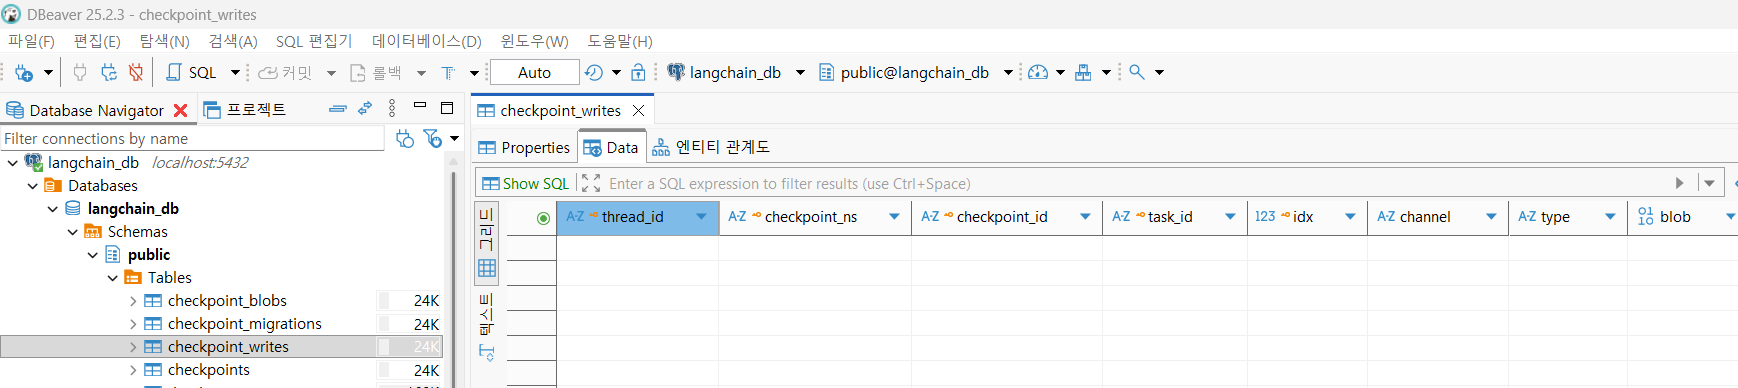

### [메모리 적용 with Human in the loop](https://docs.langchain.com/oss/python/langgraph/interrupts#debugging-with-interrupts) 

In [25]:
app = workflow.compile(
    checkpointer=checkpointer,          # 사용자의 대화내용을 암호화한 후 DB에 저장
    interrupt_before=["human_review"]   # human_review 노드 전에 실행 중단
)

print("암호화된 PostgreSQL Memory 챗봇이 준비되었습니다!")
print(f"대화 내용이 '{DB_CONFIG['database']}' 데이터베이스에 암호화되어 저장됩니다!")

암호화된 PostgreSQL Memory 챗봇이 준비되었습니다!
대화 내용이 'multiagents_db' 데이터베이스에 암호화되어 저장됩니다!


## 6단계: 그래프 시각화 (선택사항)


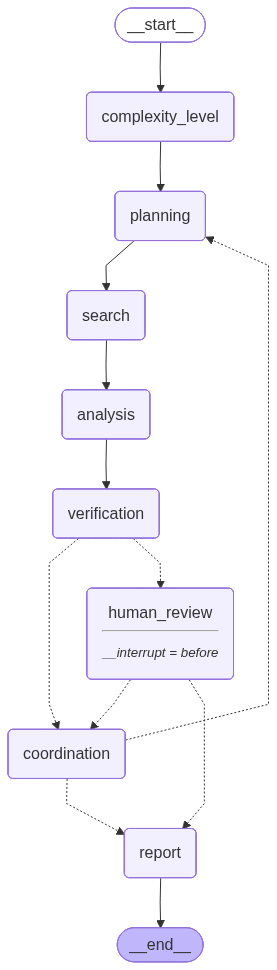

In [26]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")


## 7단계: 테스트 예제

자율 연구 시스템을 실행해봅니다.


### 연구 주제 설정


In [27]:
research_topic = "LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례"

print(f"연구 주제: {research_topic}")


연구 주제: LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례


### 자율 연구 실행 (MemorySaver 사용)

**MemorySaver 기능:**
- 각 연구 세션의 상태를 메모리에 저장
- thread_id로 여러 연구를 독립적으로 관리
- 동일한 thread_id로 실행하면 이전 상태를 이어서 진행 가능

**Human-in-the-loop:**
- 검증 단계에서 사용자 승인 요청
- 사용자가 진행 여부를 결정


In [28]:
import uuid

# 초기 상태
initial_state = {
    "topic": research_topic
}

# thread_id를 사용하여 세션 관리
# 동일한 thread_id를 사용하면 이전 상태를 이어서 진행할 수 있습니다
thread_id = str(uuid.uuid4())

# config 설정 (thread_id 포함)
config = {
    "configurable": {
        "thread_id": thread_id
    }
}

print(f"Thread ID: {thread_id}")
print("이 Thread ID로 상태가 저장됩니다.\n")

# 그래프 실행 (config와 함께)
# interrupt_before=["human_review"] 설정으로 인해 human_review 노드 전에 중단됩니다
print("그래프 실행 중...")
result = app.invoke(initial_state, config=config)

print("\n" + "=" * 80)
print("Human-in-the-loop 지점에서 실행이 중단되었습니다!")
print("다음 셀에서 승인 여부를 결정하고 실행을 재개하세요.")
print("=" * 80)


Thread ID: 4e2f0b82-83ca-4f68-ae96-c87f7c669620
이 Thread ID로 상태가 저장됩니다.

그래프 실행 중...
[주제의 복잡도 에이전트] 주제 복잡도: 복잡 (최대 4회 반복)
[계획 에이전트] 연구 계획 수립 완료 (반복 1회 / 최대 4회)
[검색 에이전트] 웹 검색 실행: LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례
[검색 에이전트] 실제 웹 검색 완료 (3개 결과)
[분석 에이전트] 데이터 분석 완료
[검증 에이전트] 추가 조사 필요

Human-in-the-loop 지점에서 실행이 중단되었습니다!
다음 셀에서 승인 여부를 결정하고 실행을 재개하세요.


### Human 검토 (1단계: 현재 상태 상세 확인)

interrupt로 중단된 시점에서 현재까지의 연구 결과를 상세히 검토합니다.


> 현재 상태 가져오기

In [29]:
# 현재 상태 가져오기
current_state = app.get_state(config)
print("\n" + "=" * 80)
print(f"기본 정보:")
print(f"  - Thread ID: {thread_id}")
print(f"  - 중단 지점: {current_state.next}")
print(f"  - 현재 반복: {current_state.values.get('iteration_count', 0)}/{current_state.values.get('max_iterations', 0)}")
print(f"  - 검증 상태: {current_state.values.get('verification_status', 'N/A')}")



기본 정보:
  - Thread ID: 4e2f0b82-83ca-4f68-ae96-c87f7c669620
  - 중단 지점: ('human_review',)
  - 현재 반복: 1/4
  - 검증 상태: needs_more_research


In [30]:
print("\n" + "=" * 80)
print(f"검증 피드백:")
print("-" * 80)
verification_feedback = current_state.values.get('verification_feedback', '없음')
print(verification_feedback)



검증 피드백:
--------------------------------------------------------------------------------
STATUS: NEEDS_MORE_RESEARCH
정보는 LangGraph의 구조와 사례를 제시하지만, 성능 근거와 실무 비교가 부족합니다. 대규모 그래프 확장성, 지연/자원 소모, 보안/프라이버시, 관찰성 메트릭 등의 구체적 근거가 필요합니다. LangGraph와 Autogen의 실무 차이 및 벤치마크 설계, 운영 지침과 표준화 이슈를 추가로 조사해야 합니다.


In [31]:
print("\n" + "=" * 80)
print(f"수집된 데이터:")
search_results = current_state.values.get('search_results', [])
analysis_results = current_state.values.get('analysis_results', [])
print(f"  - 검색 수행: {len(search_results)}회")
print(f"  - 분석 수행: {len(analysis_results)}회")

if search_results:
    print(f"최근 검색 결과 미리보기:")
    latest_search = search_results[-1]
    print(latest_search[:500] + "..." if len(latest_search) > 500 else latest_search)

if analysis_results:
    print(f"최근 분석 결과 미리보기:")
    latest_analysis = analysis_results[-1]
    print(latest_analysis[:500] + "..." if len(latest_analysis) > 500 else latest_analysis)


print("\n" + "=" * 80)
print("검토 포인트:")
print("  1. 검증 피드백을 확인하세요")
print("  2. 현재 수집된 정보가 충분한지 판단하세요")
print("  3. 추가 조사가 필요한지 결정하세요")
print("=" * 80)



수집된 데이터:
  - 검색 수행: 4회
  - 분석 수행: 2회
최근 검색 결과 미리보기:
[검색 1] LangGraph는 LangChain의 멀티에이전트 워크플로우를 그래프 형태로 구성하는 라이브러리로, Python과 JS에서 사용 가능하며 사이클이 있는 LLM 워크플로우를 다루는 데 초점을 둔다. 에이전트를 노드로, 전이를 간선으로 표현하고 각 노드의 프롬프트/도구와 전이 확률을 명시적으로 제어하는 그래프/상태 머신 관점의 워크플로우 관리가 핵심 강점이다. Autogen과의 차이는 LangGraph가 ‘그래프’ 프레이밍으로 더 직관적이고 제어를 강화하는 반면, 공유 스크래치패드를 통한 협업은 때로 모든 작업 내용을 서로 공유하게 되어 불필요하게 상세해질 수 있다는 단점이 있다. 실무 예시로는 에이전트 간 협업을 위한 ‘공유 스크래치패드’가 소개되며, 독립 에이전트는 실제로 하나의 LLM 호출과 특정 프롬프트 템플릿(시스템 메시지)으로 구성될 수 있다.
최근 분석 결과 미리보기:
[분석 1] 주요 발견사항
- LangGraph는 노드=에이전트, 간선=전이로 구성된 그래프 기반 멀티에이전트 워크플로우를 제공하며, 각 노드의 프롬프트/도구와 전이 확률을 명시적으로 제어하고 사이클이 있는 LLM 워크플로우를 다룬다.
- 그래프 프레이밍과 제어 강화로 예측성과 디버깅 용이성이 커지며, 워크플로우 제어의 명확성이 증가한다. Autogen 대비 제어의 직관성이 강점이다.
- 실제 활용 사례로는 에이전트 간 협업을 위한 공유 스크래치패드 활용과, 독립 에이전트를 하나의 LLM 호출과 특정 프롬프트 템플릿(시스템 메시지)로 구성하는 방식이 가능하다.

핵심 트렌드
- 그래프/상태 머신 접근으로 사이클 포함 복잡한 LLM 워크플로우를 체계적으로 관리하려는 경향이 강화된다.
- 협업 방식의 선택이 중요하며, 그래프 제어의 이점과 공유 스크래치패드의 과도한 정보 노출 위험 간 균형을 모색하는 흐름이 보인다.

추가 조사 필요 부분
- LangGraph vs Autogen의 

### Human 승인 (2단계: 결정 및 실행)

검토 결과를 바탕으로 다음 중 하나를 선택하세요:
- **옵션 1 (다음 셀)**: 계속 진행 (human_approval=True) - 추가 조사 수행
- **옵션 2 (그 다음 셀)**: 중단 (human_approval=False) - 현재 결과로 보고서 작성


In [32]:
# 옵션 1: 계속 진행 (승인) - 추가 조사 수행
# 검토 결과 정보가 부족하다고 판단되면 이 셀을 실행하세요

print("=" * 80)
print("옵션 1 선택: 계속 진행 (승인)")
print("=" * 80)

# 상태 업데이트: human_approval=True 설정
app.update_state(config, {"human_approval": True})

print("승인됨 - 추가 조사를 위해 실행 재개 중...")

# 실행 재개 (None을 전달하여 이전 상태에서 계속)
result = app.invoke(None, config=config)

print("\n" + "=" * 80)
print("추가 조사 완료!")
print("다음 Human-in-the-loop 지점에서 다시 중단되거나, 최종 보고서가 작성됩니다.")
print("=" * 80)


옵션 1 선택: 계속 진행 (승인)
승인됨 - 추가 조사를 위해 실행 재개 중...

[Human-in-the-loop] 사용자 검토 요청
현재 반복: 1/4
검증 상태: needs_more_research

검증 피드백:
STATUS: NEEDS_MORE_RESEARCH
정보는 LangGraph의 구조와 사례를 제시하지만, 성능 근거와 실무 비교가 부족합니다. 대규모 그래프 확장성, 지연/자원 소모, 보안/프라이버시, 관찰성 메트릭 등의 구체적 근거가 필요합니다. LangGraph와 Autogen의 실무 차이 및 벤치마크 설계, 운영 지침과 표준화 이슈를 추가로 조사해야 합니다....
이 시점에서 실행이 중단됩니다.
다음 셀에서 승인 여부를 결정하고 실행을 재개할 수 있습니다.
[조정 에이전트] 추가 조사 필요 - 검색으로 돌아갑니다 (반복 1/4)
[계획 에이전트] 연구 계획 수립 완료 (반복 2회 / 최대 4회)
[검색 에이전트] 웹 검색 실행: LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례
[검색 에이전트] 실제 웹 검색 완료 (3개 결과)
[분석 에이전트] 데이터 분석 완료
[검증 에이전트] 추가 조사 필요

추가 조사 완료!
다음 Human-in-the-loop 지점에서 다시 중단되거나, 최종 보고서가 작성됩니다.


> 현재 상태 가져오기

In [33]:
# 현재 상태 가져오기
current_state = app.get_state(config)
print("\n" + "=" * 80)
print(f"기본 정보:")
print(f"  - Thread ID: {thread_id}")
print(f"  - 중단 지점: {current_state.next}")
print(f"  - 현재 반복: {current_state.values.get('iteration_count', 0)}/{current_state.values.get('max_iterations', 0)}")
print(f"  - 검증 상태: {current_state.values.get('verification_status', 'N/A')}")



기본 정보:
  - Thread ID: 4e2f0b82-83ca-4f68-ae96-c87f7c669620
  - 중단 지점: ('human_review',)
  - 현재 반복: 2/4
  - 검증 상태: needs_more_research


### Human 거부 (3단계: 중단 후 보고서 작성)

현재 결과로 만족하고 추가 조사 없이 바로 보고서를 작성하고 싶은 경우 사용합니다.
**주의**: 옵션 1 대신 이 셀을 실행하세요.


In [34]:
# 옵션 2: 중단 후 보고서 작성 (거부) - 현재 결과로 보고서 작성
# 검토 결과 현재 정보로 충분하다고 판단되면 이 셀을 실행하세요
# 주의: 옵션 1 셀을 실행하지 않았을 때만 이 셀을 실행하세요

print("=" * 80)
print("옵션 2 선택: 중단 후 보고서 작성 (거부)")
print("=" * 80)

# 상태 업데이트: human_approval=False 설정
app.update_state(config, {"human_approval": False})

print("거부됨 - 추가 조사 없이 현재 결과로 보고서 작성 중...")

# 실행 재개 (None을 전달하여 이전 상태에서 계속)
result = app.invoke(None, config=config)

print("\n" + "=" * 80)
print("연구 완료! 최종 보고서가 작성되었습니다.")
print("=" * 80)


옵션 2 선택: 중단 후 보고서 작성 (거부)
거부됨 - 추가 조사 없이 현재 결과로 보고서 작성 중...

[Human-in-the-loop] 사용자 검토 요청
현재 반복: 2/4
검증 상태: needs_more_research

검증 피드백:
STATUS: NEEDS_MORE_RESEARCH
이 분석은 주요 발견과 트렌드를 제시하지만 실증적 근거(벤치마크, 사례 연구, 수치)가 없어 LangGraph의 이점과 한계를 확정하기 어렵다. 실무 적용을 위한 LangGraph vs Autogen 비교 연구, 성능 지표 수립, 그래프 설계 원칙, 스케일링 가이드, 보안/프라이버시 이슈를 포함한 체계적 추가 연구가 필요하다....
이 시점에서 실행이 중단됩니다.
다음 셀에서 승인 여부를 결정하고 실행을 재개할 수 있습니다.
[보고서 에이전트] 최종 보고서 작성 완료

연구 완료! 최종 보고서가 작성되었습니다.


### 최종 보고서 확인


In [35]:
print("\n" + "=" * 80)
print("최종 연구 보고서")
print("=" * 80)
print(f"\n총 반복 횟수: {result['iteration_count']}")
print(f"검증 상태: {result['verification_status']}")
print("\n" + "-" * 80)
print(result["final_report"])
print("-" * 80)



최종 연구 보고서

총 반복 횟수: 2
검증 상태: needs_more_research

--------------------------------------------------------------------------------
1. 요약
- LangGraph는 LangChain 기반의 그래프 형태 멀티에이전트 워크플로우 라이브러리로, 에이전트를 노드로, 전이를 간선으로 표현하며 사이클이 있는 흐름을 명시적으로 제어할 수 있다. 그래프 프레이밍은 제어성과 가시성을 크게 높이고 디버깅을 용이하게 하지만, 공유 스크래치패드의 정보 노출 위험과 설계 복잡성 등의 비용이 있다. 본 보고서는 LangGraph와 Autogen의 차이, 대규모 그래프 확장성, 보안/프라이버시, 관찰성, 벤치마크 설계 및 운영 표준화의 관점에서 실제 활용 사례를 바탕으로 핵심 시사점을 정리한다.

2. 주요 발견사항
- 아키텍처 및 제어 방식: LangGraph에서 에이전트는 노드, 전이 확률은 간선으로 표현되며 사이클이 허용되는 그래프/상태 머신 관점의 제어가 가능하다. 각 노드의 프롬프트/도구와 전이 확률을 그래프 단위로 명시적으로 관리한다.
- LangGraph vs Autogen의 차이: LangGraph는 그래프 프레이밍으로 흐름 제어를 강화하고 비대화 흐름의 전이까지 포착하는 반면, Autogen은 대화 중심 프레이밍에 더 의존한다. 그래프 제어의 직관성과 비대화 흐름의 투명성은 LangGraph의 주된 강점이다.
- 활용 사례의 실무 포인트: 에이전트 간 협업은 공유 스크래치패드 방식으로 투명성을 높일 수 있으며, 독립 에이전트는 하나의 LLM 호출과 고정 프롬프트 템플릿으로 구성할 수 있다.
- 이점과 한계의 균형: 그래프 제어는 예측성/디버깅 용이성, 문제 해결의 체계성 향상을 제공하지만, 스크래치패드 상의 정보 노출 위험이나 필요 시 비효율적일 수 있는 협업 방식의 단점이 있다.
- 추가 조사 필요 영역: 성능/생산성 비교, 대규모 그래프의 확장성(수천~수만 에이전

### 연구 과정 추적 및 MemorySaver(PostreSQL) 상태 확인


In [36]:
# 저장된 상태 조회
print("\n" + "=" * 80)
print("MemorySaver(PostreSQL) 상태 확인")
print("=" * 80)

# 현재 thread의 상태 가져오기
state_snapshot = app.get_state(config)

print(f"\nThread ID: {thread_id}")
print(f"현재 상태:")
print(f"  - 반복 횟수: {state_snapshot.values.get('iteration_count', 0)}")
print(f"  - 최대 반복 횟수: {state_snapshot.values.get('max_iterations', 0)}")
print(f"  - 검증 상태: {state_snapshot.values.get('verification_status', 'N/A')}")
print(f"  - Human 승인: {state_snapshot.values.get('human_approval', 'N/A')}")
print(f"  - 검색 결과 수: {len(state_snapshot.values.get('search_results', []))}")
print(f"  - 분석 결과 수: {len(state_snapshot.values.get('analysis_results', []))}")



MemorySaver(PostreSQL) 상태 확인

Thread ID: 4e2f0b82-83ca-4f68-ae96-c87f7c669620
현재 상태:
  - 반복 횟수: 2
  - 최대 반복 횟수: 4
  - 검증 상태: needs_more_research
  - Human 승인: False
  - 검색 결과 수: 528
  - 분석 결과 수: 264


In [37]:
print("\n" + "=" * 80)
print("연구 과정 추적")
print("=" * 80)

search_results = result.get('search_results', [])
analysis_results = result.get('analysis_results', [])

print(f"\n[검색 결과 수집]: {len(search_results)}회")
for i, search in enumerate(search_results, 1):
    print(f"\n--- 검색 {i} ---")
    print(search[:200] + "..." if len(search) > 200 else search)

print(f"\n\n[분석 수행]: {len(analysis_results)}회")
for i, analysis in enumerate(analysis_results, 1):
    print(f"\n--- 분석 {i} ---")
    print(analysis[:200] + "..." if len(analysis) > 200 else analysis)



연구 과정 추적

[검색 결과 수집]: 528회

--- 검색 1 ---
[검색 1] LangGraph는 LangChain의 멀티에이전트 워크플로우를 그래프 형태로 구성하는 라이브러리로, Python과 JS에서 사용 가능하며 사이클이 있는 LLM 워크플로우를 다루는 데 초점을 둔다. 에이전트를 노드로, 전이를 간선으로 표현하고 각 노드의 프롬프트/도구와 전이 확률을 명시적으로 제어하는 그래프/상태 머신 관점의 워크플로우 관리가 ...

--- 검색 2 ---
[검색 1] LangGraph는 LangChain의 멀티에이전트 워크플로우를 그래프 형태로 구성하는 라이브러리로, Python과 JS에서 사용 가능하며 사이클이 있는 LLM 워크플로우를 다루는 데 초점을 둔다. 에이전트를 노드로, 전이를 간선으로 표현하고 각 노드의 프롬프트/도구와 전이 확률을 명시적으로 제어하는 그래프/상태 머신 관점의 워크플로우 관리가 ...

--- 검색 3 ---
[검색 1] LangGraph는 LangChain의 멀티에이전트 워크플로우를 그래프 형태로 구성하는 라이브러리로, Python과 JS에서 사용 가능하며 사이클이 있는 LLM 워크플로우를 다루는 데 초점을 둔다. 에이전트를 노드로, 전이를 간선으로 표현하고 각 노드의 프롬프트/도구와 전이 확률을 명시적으로 제어하는 그래프/상태 머신 관점의 워크플로우 관리가 ...

--- 검색 4 ---
[검색 1] LangGraph는 LangChain의 멀티에이전트 워크플로우를 그래프 형태로 구성하는 라이브러리로, Python과 JS에서 사용 가능하며 사이클이 있는 LLM 워크플로우를 다루는 데 초점을 둔다. 에이전트를 노드로, 전이를 간선으로 표현하고 각 노드의 프롬프트/도구와 전이 확률을 명시적으로 제어하는 그래프/상태 머신 관점의 워크플로우 관리가 ...

--- 검색 5 ---
[검색 1] LangGraph는 LangChain의 멀티에이전트 워크플로우를 그래프 형태로 구성하는 라이브러리로, Python과 JS에서 사용 가능하며 사

#### 암호화된 데이터 확인 

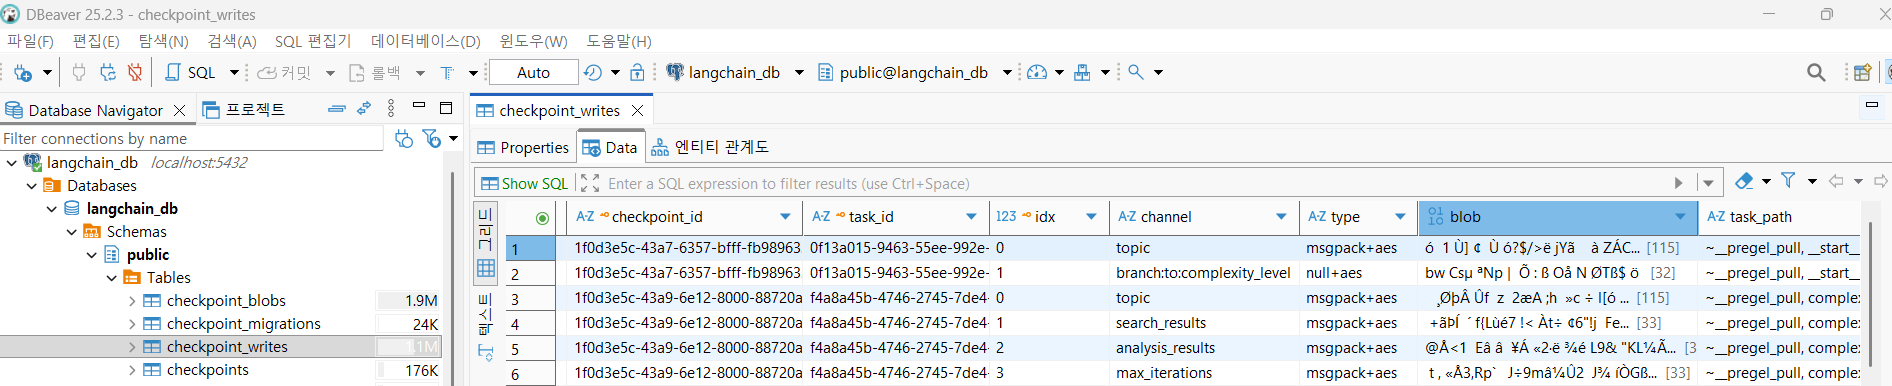

### [Langsmith](https://smith.langchain.com/)

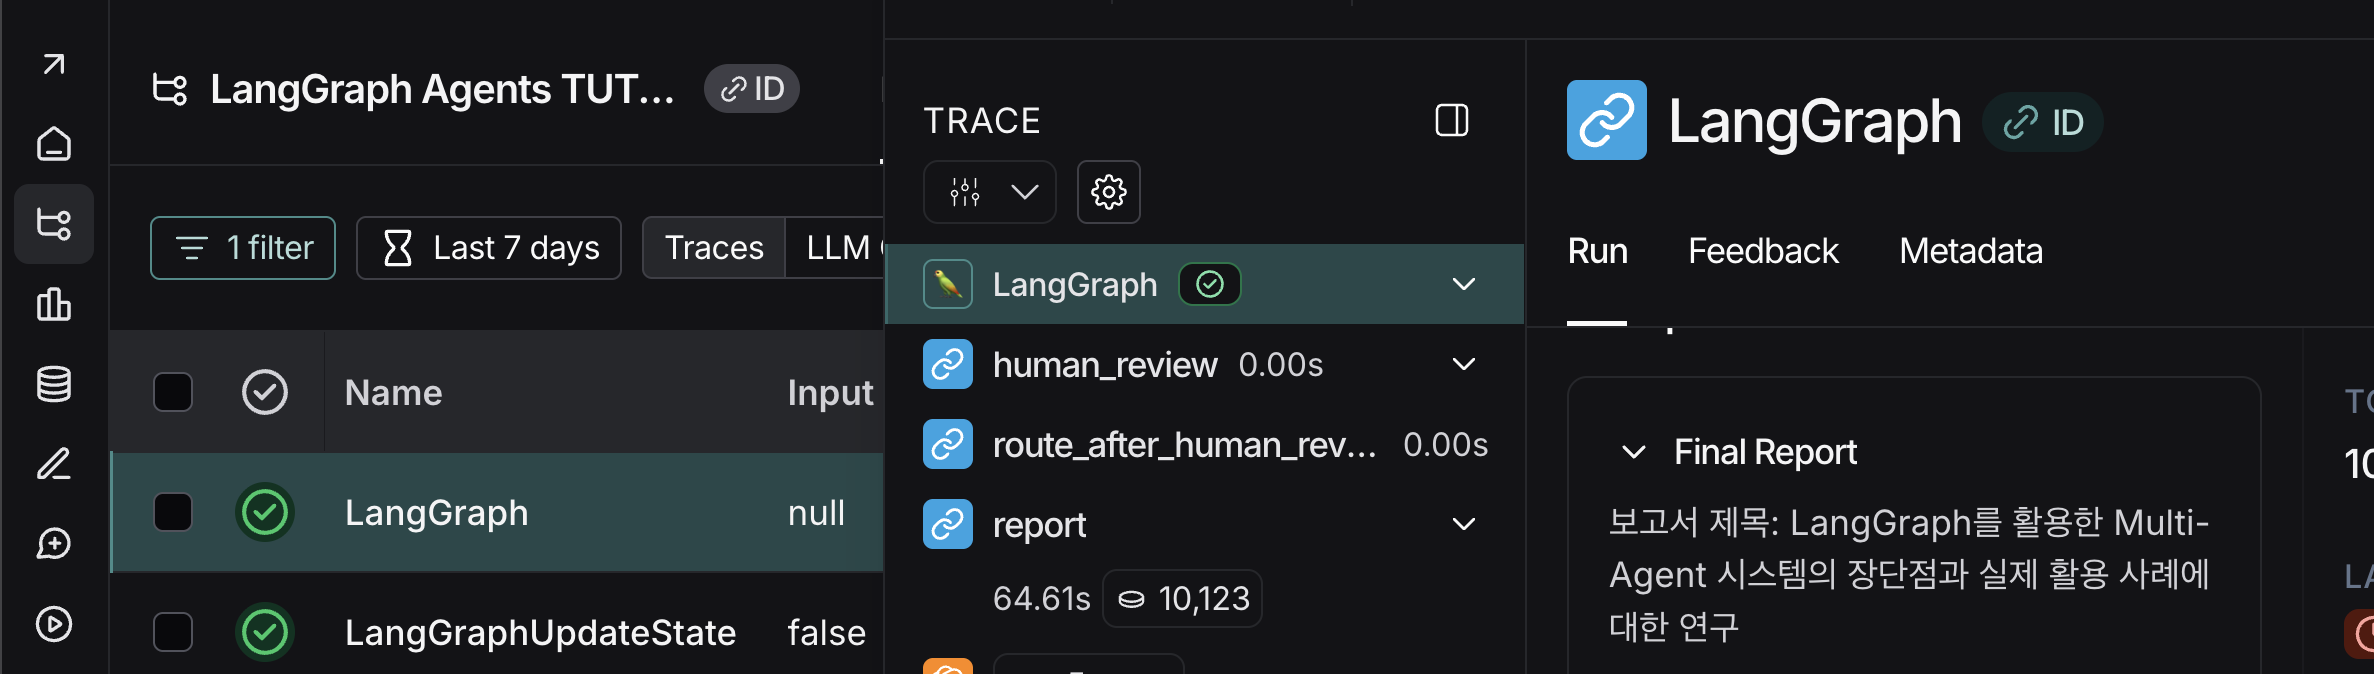